# PRELUDE

Before starting this notebook, I want you to explore the examples of commercial SAR data in data/commercial_cog. There are a few examples. There are examples of Stripmap, Sliding Spotlight, and Spotlight modes. Pay attention to how the resolution of individual structures changes between the different modes.

**QUESTION (20 pts):**
The scene 

CAPELLA_C13_SP_GEO_HH_20250601220547_20250601220630_preview

shows the immediate aftermath (same day scene acquisition) of a Ukrainian drone attack on Belaya air base in central Russia on June 01 2025. This scene is a good example of what intact vs destroyed small structures look like in commercial SAR data. Intelligence agencies reported based on this scene that 3 large and 4 smaller aircraft were destroyed. Spend a few minutes looking through this scene, and print screen 2-3 examples of destroyed aircraft, and 2-3 examples of in-tack aircraft. Upload your examples as a separate pdf with a brief description of how you made this distinction. This type of analysis is common in both intelligence and disaster response applications, as structures destroyed by wildfire/earthquakes/hurricanes/etc. will show similar features, but those tend to be very messy scenes and difficult to interperet. 

**ANSWER: Upload examples along with this notebook.**

# Ship Detection in Commercial SAR Subsets

You have already explored commercial SAR scenes outside this notebook. Here you will process a prepared subset containing ships and build a simple brightness-based ship-candidate detector.

The detector identifies bright object candidates. It does not prove that an object is a ship.

This workflow is designed to get you familiar with the types of problems being addressed with commercial SAR data. There are 

## Learning objectives

By the end of this notebook, you should be able to load a SAR subset, display it, test brightness thresholds, group bright pixels into connected components, filter candidate objects, draw bounding boxes, and explain false positives.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from scipy.ndimage import label, find_objects, binary_closing
from matplotlib.patches import Rectangle

## 2. Read one SAR subset

We are using a commercial SAR preview COG. Pixel values are 8-bit display brightness values. We will use them for visual interpretation and simple bright-target detection, not calibrated radiometric analysis.

In [4]:
#SCENE_INDEX = 0

path = r".\data\commercial_cog_subset\ship_subset.tif" 

with rasterio.open(path) as src:
    arr = src.read(1)
    meta = {
        "width": src.width,
        "height": src.height,
        "count": src.count,
        "dtype": src.dtypes,
        "crs": src.crs,
        "resolution": src.res,
        "bounds": src.bounds,
        "nodata": src.nodata,
    }

print()
for k, v in meta.items():
    print(f"{k}: {v}")

print("Array shape:", arr.shape)
print("Array dtype:", arr.dtype)
print("Min/max:", np.nanmin(arr), np.nanmax(arr))

nodata = meta["nodata"] if meta["nodata"] is not None else 0
valid = np.isfinite(arr) & (arr != nodata)
print("Valid percentiles:", np.nanpercentile(arr[valid], [1, 50, 95, 99, 99.8, 99.9]))


width: 9381
height: 8141
count: 1
dtype: ('uint8',)
crs: EPSG:32618
resolution: (0.34999999999999054, 0.34999999999999054)
bounds: BoundingBox(left=579373.1451899222, bottom=4500843.217511419, right=582656.495189922, top=4503692.567511419)
nodata: 0.0
Array shape: (8141, 9381)
Array dtype: uint8
Min/max: 1 255
Valid percentiles: [  1.  22.  72.  85. 136. 158.]


## 3. Display the SAR subset

For Capella preview imagery, values may already be 8-bit display values. We use a percentile stretch and ignore nodata.

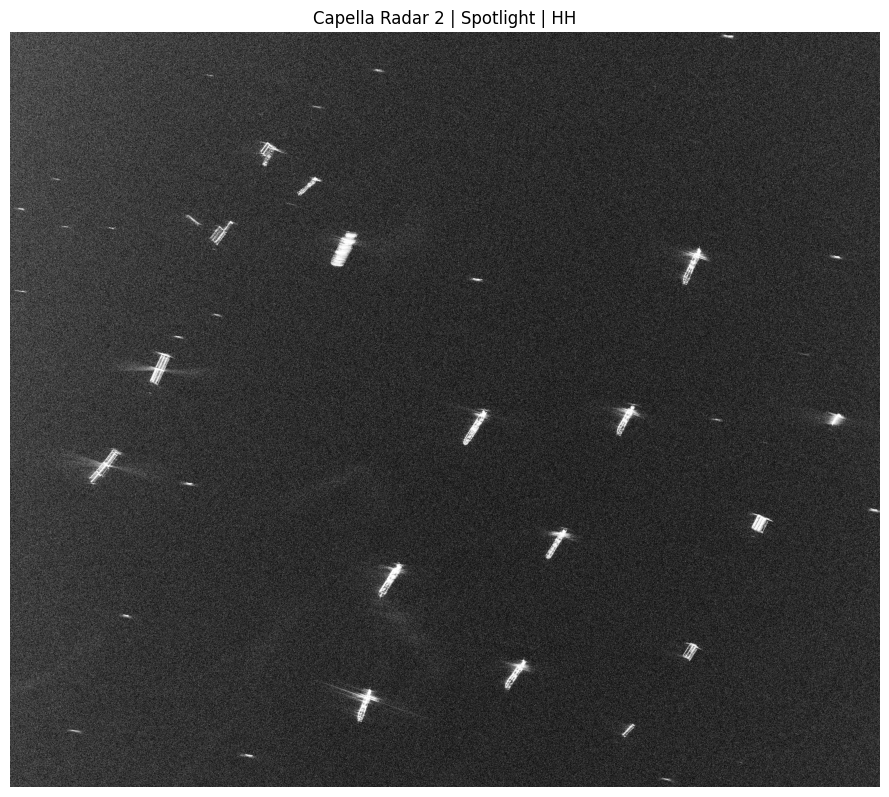

In [5]:
def display_sar(arr, pmin=1, pmax=99.8, nodata=0):
    img = arr.astype("float32").copy()
    if nodata is not None:
        img[img == nodata] = np.nan

    finite = np.isfinite(img)
    if not finite.any():
        return np.zeros_like(img, dtype="float32")

    lo, hi = np.nanpercentile(img[finite], [pmin, pmax])
    return np.clip((img - lo) / (hi - lo + 1e-9), 0, 1)

def plot_sar(arr, title="", pmin=1, pmax=99.8, nodata=0, figsize=(9, 9)):
    disp = display_sar(arr, pmin=pmin, pmax=pmax, nodata=nodata)
    plt.figure(figsize=figsize)
    plt.imshow(disp, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_sar(arr, title=f"Capella Radar 2 | Spotlight | HH", nodata=nodata)

### Questions

1. Identify several bright targets that are likely ships.
2. Do all ships appear as single blobs?
**QUESTION (5 pts):Zoom in very closely to some large ships in your GIS program. Do all ships still appear as single blobs? What might be some difficulty in designing a detector that can isolate single ships vs multiple clustered ships?**

**ANSWER:**

## 4. Test brightness thresholds

A first simple detector is: `ship candidate pixel = brightness >= threshold`.

In [ ]:
def plot_threshold_mask(arr, threshold, nodata=0, pmin=1, pmax=99.8):
    img = arr.astype("float32")
    valid = np.isfinite(img)
    if nodata is not None:
        valid &= img != nodata
    mask = (img >= threshold) & valid

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(display_sar(arr, pmin=pmin, pmax=pmax, nodata=nodata), cmap="gray")
    axes[0].set_title("SAR image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(f"Brightness mask: value >= {threshold}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print("Pixels above threshold:", int(mask.sum()))
    print("Fraction of valid pixels above threshold:", float(mask.sum() / valid.sum()))
    return mask

mask = plot_threshold_mask(arr, threshold=150, nodata=nodata)

The brightest ships show here, but this misses smaller ships. We will need a smaller threshold to capture as many ships as we can. Test a few different thresholds below. 

In [ ]:
###TRY SOME DIFFERENT THRESHOLDS HERE. PUT YOUR THRESHOLDS IN THE BRACKETS
for threshold in []:
    print("\nThreshold:", threshold)
    _ = plot_threshold_mask(arr, threshold=threshold, nodata=nodata)

**QUESTION (10 pts):**
1. Which threshold seems too low?
2. Which threshold seems too high?
3. Which threshold would you choose for a first-pass detector?
4. What types of ships or ship parts might be missed by a high threshold?

**ANSWER:**

## 5. Connected components

The threshold mask marks bright pixels, not objects. Connected-component labeling groups adjacent bright pixels into candidate objects.

In [ ]:
def connected_component_table(mask, arr):
    labeled, n_labels = label(mask)
    objects = find_objects(labeled)
    img = arr.astype("float32")
    rows = []

    for object_id, slc in enumerate(objects, start=1):
        if slc is None:
            continue
        rr, cc = slc
        component = labeled[slc] == object_id
        y0, y1 = rr.start, rr.stop
        x0, x1 = cc.start, cc.stop
        area = int(component.sum())
        width = x1 - x0
        height = y1 - y0
        values = img[slc][component]
        rows.append({
            "object_id": object_id,
            "x0": x0, "y0": y0, "x1": x1, "y1": y1,
            "width_pix": width, "height_pix": height, "area_pix": area,
            "mean_brightness": float(np.nanmean(values)),
            "max_brightness": float(np.nanmax(values)),
        })

    table = pd.DataFrame(rows)
    if len(table):
        table = table.sort_values(["max_brightness", "area_pix"], ascending=False).reset_index(drop=True)
    return table, labeled

threshold = 100
img = arr.astype("float32")
valid = np.isfinite(img) & (img != nodata)
mask = (img >= threshold) & valid
component_table, labeled = connected_component_table(mask, arr)
print("Number of connected components:", len(component_table))
display(component_table.head(20))

**QUESTION (5 pts): Look at the number of connected components, printed before the table. Does that match with the approximate number of ships you think you should see? NOTE: The above and below cells only plot connected components and bounding boxes for a small subset of what was found. You can play with these values, but the image might get hard to read.**

**ANSWER:**

## 6. Plot bounding boxes

In [ ]:
def plot_boxes(arr, candidates, title="Candidate boxes", nodata=0, pmin=1, pmax=99.8, max_boxes=100, label_boxes=True, figsize=(10, 10)):
    disp = display_sar(arr, pmin=pmin, pmax=pmax, nodata=nodata)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(disp, cmap="gray")
    ax.set_title(title)

    for i, (_, r) in enumerate(candidates.head(max_boxes).iterrows(), start=1):
        rect = Rectangle((r["x0"], r["y0"]), r["x1"] - r["x0"], r["y1"] - r["y0"], fill=False, linewidth=1.5)
        ax.add_patch(rect)
        if label_boxes:
            ax.text(r["x0"], max(r["y0"] - 3, 0), str(i), fontsize=8, bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1))

    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_boxes(arr, component_table.head(100), title=f"Unfiltered connected components, threshold={threshold}", nodata=nodata)

## 7. Precompiled reference detector

Use this to experiment with parameters before completing your own final detector.

In [ ]:
def detect_ship_candidates_precompiled(arr, threshold=100, nodata=0, min_area=4, max_area=500, max_width=120, max_height=120, min_aspect=0.1, max_aspect=10.0, do_closing=True):
    img = arr.astype("float32")
    valid = np.isfinite(img)
    if nodata is not None:
        valid &= img != nodata

    mask = (img >= threshold) & valid
    if do_closing:
        mask = binary_closing(mask, structure=np.ones((2, 2)))

    labeled, n_labels = label(mask)
    objects = find_objects(labeled)
    rows = []

    for object_id, slc in enumerate(objects, start=1):
        if slc is None:
            continue
        rr, cc = slc
        component = labeled[slc] == object_id
        area = int(component.sum())
        if area < min_area or area > max_area:
            continue

        y0, y1 = rr.start, rr.stop
        x0, x1 = cc.start, cc.stop
        width = x1 - x0
        height = y1 - y0
        aspect = width / max(height, 1)

        if width > max_width or height > max_height:
            continue
        if aspect < min_aspect or aspect > max_aspect:
            continue

        values = img[slc][component]
        rows.append({
            "candidate_id": object_id,
            "x0": x0, "y0": y0, "x1": x1, "y1": y1,
            "center_x": 0.5 * (x0 + x1),
            "center_y": 0.5 * (y0 + y1),
            "width_pix": width, "height_pix": height, "area_pix": area, "aspect": aspect,
            "mean_brightness": float(np.nanmean(values)),
            "max_brightness": float(np.nanmax(values)),
        })

    candidates = pd.DataFrame(rows)
    if len(candidates):
        candidates = candidates.sort_values(["max_brightness", "area_pix"], ascending=False).reset_index(drop=True)
    return candidates, mask, labeled

In [ ]:
test_candidates, test_mask, test_labeled = detect_ship_candidates_precompiled(arr, threshold=100, nodata=nodata, min_area=4, max_area=500, max_width=120, max_height=120, do_closing=True)
print("Detected candidates:", len(test_candidates))
display(test_candidates.head(30))
plot_boxes(arr, test_candidates, title="Filtered ship candidates", nodata=nodata, max_boxes=1000)

The cell below will allow you to test a few different thresholds and areas at the same time. NOTE: If processing is too slow on your laptop, you can always take a smaller subset from QGIS for testing.

In [ ]:
settings = [
    {"threshold": 100, "min_area": 3, "max_area": 800},
    {"threshold": 100, "min_area": 4, "max_area": 500},
    {"threshold": 80, "min_area": 4, "max_area": 500},
]

for s in settings:
    candidates, _, _ = detect_ship_candidates_precompiled(arr, nodata=nodata, max_width=120, max_height=120, do_closing=True, **s)
    print("\nSettings:", s)
    print("Candidate count:", len(candidates))
    plot_boxes(arr, candidates, title=f"threshold={s['threshold']}, min_area={s['min_area']}, max_area={s['max_area']}", nodata=nodata, max_boxes=1000, figsize=(8, 8))

**QUESTION (10 pts):**
1. Which settings produce too many false positives?
2. Which settings miss obvious ships?
3. Do larger ships split into multiple components?

**ANSWER:**

# 8. Final coding exercise — finish the ship detector

**QUESTION (30 pts):**
Adjust the detect_ship_candidates_precompiled() function above to group these candidate detections into individual ships. Right now, single ships are clusters of several to many different individual pieces - this is expected becasue SAR images of individual structures like boats are not uniformly illuminated, meaning there will often be gaps in bright spots. I found the scipy package binary_dilation to be very useful to add here. You will need to adjust the binary_closing if statement to first do binary_dilation, while also getting the structure correct with the merge_distance_pix variable. When compiling the summary statistics table at the end, it will be important to use the original bright pixels inside your grouped boxes to compute brightness, not the dilated pixels. The following code block will help with that:

        original_component_pixels = img[y0:y1, x0:x1]
        original_valid = valid[y0:y1, x0:x1]
        original_bright = (original_component_pixels >= threshold) & original_valid


In [ ]:
from scipy.ndimage import binary_dilation


def detect_ship_candidates_grouped(
    arr,
    threshold=100,
    nodata=0,
    min_area=4,
    max_area=50000,
    max_width=600,
    max_height=600,
    min_aspect=0.05,
    max_aspect=30.0,
    merge_distance_pix=15,
    do_closing=True,
):
###YOUR CODE HERE. COPY THE ORIGINAL detect_ship_candidates FUNCTION, AND ADJUST TO DO THE GROUPING

The following cells run and plot the above function.

In [ ]:
candidates, mask, labeled = detect_ship_candidates_grouped(
    arr,
    threshold=120,
    nodata=0,
    min_area=20,
    max_area=70000,
    max_width=700,
    max_height=700,
    merge_distance_pix=20,
)
print("candidate rows:", len(candidates))
print(candidates.head(30).to_string(index=False))

plot_boxes(
    arr,
    candidates,
    title="Grouped ship candidates",
    nodata=0,
    max_boxes=1000,
)

## 9. Short interpretation note
**QUESTION (20 pts):**
Write 1 paragraph describing which parameters you settled on and why.

- Which threshold and size filters did you choose?
- Did your detector mostly find ships, or did it also detect clutter?
- What false positives remain? What false negatives remain?
- What types of ships might be missed?

**ANSWER:**



## Optional extension

Run the same detector on another subset, such as a Sliding Spotlight or Stripmap scene. Do the same thresholds work? Which mode makes ship detection easiest?

In [ ]:
# OPTIONAL: try another scene from the manifest.

# SCENE_INDEX = 1
# row = df.iloc[SCENE_INDEX]
# path = ROOT / row["local_path"]
#
# with rasterio.open(path) as src:
#     arr2 = src.read(1)
#     nodata2 = src.nodata if src.nodata is not None else 0
#
# plot_sar(arr2, title=f"{row['scene_id']} | {row['mode']} | {row['polarization']}", nodata=nodata2)
#
# candidates2, mask2, labeled2 = detect_ship_candidates(arr2, threshold=210, nodata=nodata2, min_area=4, max_area=500, max_width=120, max_height=120, do_closing=True)
# print("Detected candidates:", len(candidates2))
# display(candidates2.head(30))
# plot_boxes(arr2, candidates2, title="Optional second-scene detections", nodata=nodata2)